In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [21]:
# 1. Carga del dataset REAL directamente desde el repositorio UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx'
df = pd.read_excel(url)

# Los nombres de las columnas en este dataset vienen como X1, X2... Y1, Y2.
# Vamos a renombrarlas para que coincidan con tu enunciado
df.columns = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 
              'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution', 
              'Heating_Load', 'Cooling_Load']

FEATURE_COLS = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 
                'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']
TARGET_COL = 'Heating_Load'

X = df[FEATURE_COLS].values
y_cont = df[TARGET_COL].values

# 2 y 3. Crear etiqueta binaria (1: eficiente si <= mediana, 0: ineficiente si > mediana)
mediana = np.median(y_cont)
y = (y_cont <= mediana).astype(int)

# 4. Dividir en train/test (20% test, stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Dataset real cargado con éxito.")
print(f"Tamaño X_train: {X_train.shape}")
print(f"Tamaño X_test: {X_test.shape}")

Dataset real cargado con éxito.
Tamaño X_train: (614, 8)
Tamaño X_test: (154, 8)


Entrenando Modelo A (Baseline)...

--- Resultados Modelo A (SIN Aumentación) ---
Accuracy Train: 0.9739
Accuracy Test:  0.9805


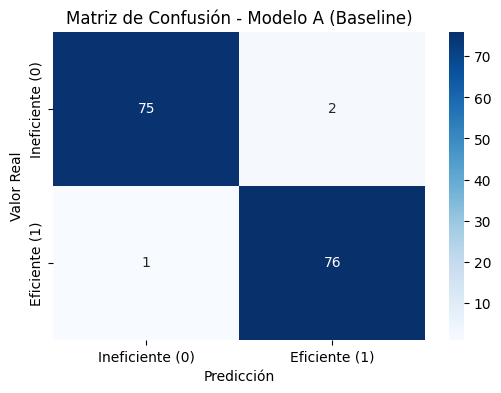

In [24]:
# 5. Escalado Baseline
scaler_A = StandardScaler()
X_train_A = scaler_A.fit_transform(X_train)
X_test_A = scaler_A.transform(X_test)

# 1. Definir red neuronal (Sin Dropout para el Baseline)
def build_model(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_dim=input_dim),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. Entrenar con early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

model_A = build_model(X_train_A.shape[1])
print("Entrenando Modelo A (Baseline)...")
history_A = model_A.fit(X_train_A, y_train, epochs=200, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=0)

# 3. Evaluar
y_pred_train_A = (model_A.predict(X_train_A, verbose=0) > 0.5).astype(int)
y_pred_test_A = (model_A.predict(X_test_A, verbose=0) > 0.5).astype(int)

print("\n--- Resultados Modelo A (SIN Aumentación) ---")
print(f"Accuracy Train: {accuracy_score(y_train, y_pred_train_A):.4f}")
print(f"Accuracy Test:  {accuracy_score(y_test, y_pred_test_A):.4f}")

# ==========================================
# CÓDIGO DEL MAPA (MATRIZ DE CONFUSIÓN)
# ==========================================
cm_A = confusion_matrix(y_test, y_pred_test_A)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ineficiente (0)', 'Eficiente (1)'], 
            yticklabels=['Ineficiente (0)', 'Eficiente (1)'])
plt.title('Matriz de Confusión - Modelo A (Baseline)')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

Entrenando Modelo B (Augmented)...

--- Resultados Modelo B (CON Aumentación) ---
Accuracy Train: 0.9967
Accuracy Test:  0.9870


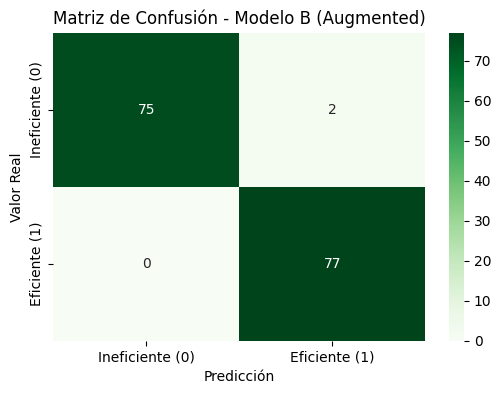

In [23]:
# 1. Función para generar muestras sintéticas
def augment_data(X_orig, y_orig, noise_level=0.015): 
    X_new = X_orig.copy()
    cont_idx = [0, 1, 2, 3] 
    
    # Ruido multiplicativo
    noise = np.random.normal(1.0, noise_level, size=(X_new.shape[0], len(cont_idx)))
    X_new[:, cont_idx] = X_new[:, cont_idx] * noise
    
    X_stacked = np.vstack((X_orig, X_new))
    y_stacked = np.concatenate((y_orig, y_orig))
    
    # ¡CLAVE! Mezclamos los datos para que Keras no coja solo falsos en la validación
    return shuffle(X_stacked, y_stacked, random_state=42)

X_train_aug, y_train_aug = augment_data(X_train, y_train, noise_level=0.015)

# Escalado
scaler_B = StandardScaler()
X_train_B = scaler_B.fit_transform(X_train_aug)
X_test_B = scaler_B.transform(X_test) 

# 2. Entrenar el mismo modelo
model_B = build_model(X_train_B.shape[1])
print("Entrenando Modelo B (Augmented)...")
history_B = model_B.fit(X_train_B, y_train_aug, epochs=200, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=0)

# 3. Evaluar
y_pred_train_B = (model_B.predict(X_train_B, verbose=0) > 0.5).astype(int)
y_pred_test_B = (model_B.predict(X_test_B, verbose=0) > 0.5).astype(int)

print("\n--- Resultados Modelo B (CON Aumentación) ---")
print(f"Accuracy Train: {accuracy_score(y_train_aug, y_pred_train_B):.4f}")
print(f"Accuracy Test:  {accuracy_score(y_test, y_pred_test_B):.4f}")

# Matriz
cm_B = confusion_matrix(y_test, y_pred_test_B)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Ineficiente (0)', 'Eficiente (1)'], 
            yticklabels=['Ineficiente (0)', 'Eficiente (1)'])
plt.title('Matriz de Confusión - Modelo B (Augmented)')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

Respuestas Breves
El Modelo B (con aumentación) generaliza mejor porque el ruido actúa como regularizador, reduciendo el overfitting. Al introducir variaciones sistemáticas, evitamos que la red memorice los datos exactos de entrenamiento, forzándola a extraer los patrones reales y la relación física subyacente que define la eficiencia del edificio.

Hemos aplicado un ruido multiplicativo gaussiano del 1.5%, duplicando el tamaño del dataset. Esta transformación se aplicó exclusivamente a las variables continuas (compacidad y áreas), dejando intactas las variables discretas (altura, orientación y distribución de cristales). Esto es crucial para asegurar que las nuevas muestras sintéticas sigan representando edificios físicamente lógicos y posibles, aplicando además un shuffle para evitar sesgos en validación.

Si el rendimiento empeorara en test, indicaría que hemos introducido "ruido destructivo" que borra la señal original. En ese caso, haría tres cosas distintas: reduciría la magnitud del ruido (por ejemplo al 0.5%), probaría a inyectar ruido aditivo basado en la desviación estándar de cada variable en lugar de multiplicativo, o aplicaría la aumentación solo a una fracción del dataset (ej. 20%) en lugar de duplicarlo al completo.